# Clinical analysis: MS patients - longitudinal - residual BAG

This notebook investigates whether longitudinal changes in clinical measures are associated with residual brain age gap (residual BAG) in MS patients.

The analyses compare:
- the unsmoothed model 
- the smoothed model

The clinical outcomes considered are:
- EDSS
- fatigue

Residual BAG is used as the brain age measure throughout this notebook. A similar notebook with adjusted BAG as the brain age measure is also made.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import pearsonr
from scipy import stats

In [2]:
# Define paths
project_path = Path("/Users/anneaasengen/MS_project")
fatigue_csv = project_path / "Metadata_OFAMS" / "fatigue.csv"

In [3]:
# Load csv files
df_unsmooth = pd.read_csv(project_path / "MS_longitudinal_unsmoothed_adjBAG.csv") # Predictions from unsmoothed model (with EDSS info)
df_smooth = pd.read_csv(project_path / "MS_longitudinal_smoothed_adjBAG.csv") # Predictions from smoothed model (with EDSS info)
df_fatigue = pd.read_csv(fatigue_csv) # Fatigue info

In [4]:
# Prepare the fatigue data and merge it into the prediction DataFrames

# Make a copy so that the original fatigue DataFrame remains unchanged
df_fatigue_clean = df_fatigue.copy()

# Rename the participant identifier column so that it matches the prediction DataFrames
df_fatigue_clean = df_fatigue_clean.rename(columns={"eid": "participant_id"})

# Convert session numbering to the same time variable used in the prediction files
df_fatigue_clean["time"] = df_fatigue_clean["session"] - 1

# Keep only the columns needed for the longitudinal clinical analysis
df_fatigue_clean = df_fatigue_clean[["participant_id", "time", "fatigue"]].copy()

# Merge fatigue info into main dataframes
df_unsmooth = df_unsmooth.merge(df_fatigue_clean,on=["participant_id", "time"],how="left") # Unsmoothed model
df_smooth = df_smooth.merge(df_fatigue_clean,on=["participant_id", "time"],how="left") # Smoothed model

In [5]:
df_unsmooth.head(8)

,participant_id,time,sex,age,EDSS,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,disease_duration,symptom_duration,BAG_residual,BAG_adj,fatigue
0,101,0,F,35.00,1.5,33.492504,-1.507496,33.919716,-1.080284,mild,0.000000,2.000000,-11.754648,-10.234101,6.888889
1,101,1,F,35.08,NaN,38.153460,3.073461,38.525620,3.445620,NaN,0.083333,2.083333,-7.135907,-5.649119,NaN
2,101,6,F,35.50,2.0,42.360916,6.860916,42.683376,7.183376,mild,0.500000,2.500000,-3.150091,-1.829922,6.777778
3,101,12,F,36.00,2.0,37.604240,1.604240,37.982887,1.982887,mild,1.000000,3.000000,-8.170622,-7.050831,6.888889
4,101,24,F,37.00,2.0,41.782860,4.782860,42.112150,5.112148,mild,2.000000,4.000000,-4.519713,-3.800677,6.444444
5,101,120,F,47.00,2.0,55.269672,8.269672,55.439660,8.439659,mild,10.000000,12.000000,3.689994,1.420123,NaN
6,103,0,M,24.00,2.5,40.867573,16.867573,41.207672,17.207672,mild,1.000000,2.000000,1.425237,1.100796,2.000000
7,103,1,M,24.08,NaN,35.914500,11.834501,36.313107,12.233107,NaN,1.083333,2.083333,-3.570052,-3.928250,NaN


In [6]:
df_smooth.head()

,participant_id,time,sex,age,EDSS,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,disease_duration,symptom_duration,BAG_residual,BAG_adj,fatigue
0,101,0,F,35.00,1.5,32.195694,-2.804306,32.905727,-2.094273,mild,0.000000,2.000000,-6.545684,-5.253175,6.888889
1,101,1,F,35.08,NaN,32.854310,-2.225691,33.554516,-1.525484,NaN,0.083333,2.083333,-5.924251,-4.664049,NaN
2,101,6,F,35.50,2.0,45.781870,10.281872,46.289124,10.789124,mild,0.500000,2.500000,6.808108,7.907943,6.777778
3,101,12,F,36.00,2.0,30.176420,-5.823580,31.385036,-4.614964,mild,1.000000,3.000000,-9.029729,-8.122569,6.888889
4,101,24,F,37.00,2.0,41.214910,4.214909,41.790325,4.790325,mild,2.000000,4.000000,1.543988,2.065799,6.444444


## ΔBAG - change from baseline

ΔBAG represents the change in brain age gap over time. In this notebook, ΔBAG is calculated from residual BAG values.

ΔBAG = BAG_last − BAG_baseline

Interpretation:
- ΔBAG > 0 indicates that residual BAG increased over time.
- ΔBAG = 0 indicates no change in residual BAG.
- ΔBAG < 0 indicates that residual BAG decreased over time.

For EDSS, the change is calculated from baseline to month 120. For fatigue, the change is calculated from baseline to month 24 because fatigue data are not available at month 120.


In [7]:
def make_delta_df(df, bag_col):
    """
    Create a subject-level DataFrame containing change scores from baseline.

    For each participant, the function extracts:
    - baseline values
    - month 24 values
    - month 120 values

    It then calculates:
    - ΔBAG and ΔEDSS from baseline to month 120
    - ΔBAG_f and Δfatigue from baseline to month 24

    The separate ΔBAG_f variable is used for fatigue because fatigue data are
    not available at month 120.
    """

    # List used to store one summary row per participant
    delta_data = []

    # Loop through each participant separately
    for pid, group in df.groupby("participant_id"):

        # Sort the participant's rows by time so that time points are ordered
        group = group.sort_values("time")

        # Select the time points required for the delta analyses
        baseline_rows = group[group["time"] == 0]
        month24_rows = group[group["time"] == 24]
        month120_rows = group[group["time"] == 120]

        # Skip participants who do not have all required time points
        # This ensures that the change scores are calculated from complete cases
        if baseline_rows.empty or month24_rows.empty or month120_rows.empty:
            continue

        # Extract the first row from each selected time point
        baseline = baseline_rows.iloc[0]
        month24 = month24_rows.iloc[0]
        month120 = month120_rows.iloc[0]

        # EDSS analysis:
        # ΔBAG and ΔEDSS: baseline to month 120
        delta_bag = month120[bag_col] - baseline[bag_col]
        delta_edss = month120["EDSS"] - baseline["EDSS"]

        # Fatigue analysis:
        # ΔBAG_f and Δfatigue: baseline to month 24 (because there is no fatigue info at month 120)
        if "fatigue" in group.columns:
            delta_BAG_f = month24[bag_col] - baseline[bag_col]
            delta_fatigue = month24["fatigue"] - baseline["fatigue"]
        else:
            delta_BAG_f = np.nan
            delta_fatigue = np.nan

        # Store all values needed for later plots and correlations
        delta_data.append({
            "participant_id": pid,
            "BAG_BL": baseline[bag_col],

            # EDSS analysis: baseline to month 120
            "delta_BAG": delta_bag,
            "delta_EDSS": delta_edss,

            # Fatigue analysis: baseline to month 24
            "delta_BAG_f": delta_BAG_f,
            "delta_fatigue": delta_fatigue,

            # Baseline clinical scores
            "EDSS_BL": baseline["EDSS"],
            "fatigue_BL": baseline["fatigue"] if "fatigue" in group.columns else np.nan,

            # Store the time points used for each analysis
            "time_BAG_EDSS": month120["time"],
            "time_BAG_fatigue": month24["time"]
        })

    # Convert the list of participant-level dictionaries to a DataFrame
    return pd.DataFrame(delta_data)

In [8]:
df_delta_unsmooth = make_delta_df(df_unsmooth, bag_col="BAG_residual")
df_delta_smooth = make_delta_df(df_smooth, bag_col="BAG_residual")

In [9]:
df_delta_unsmooth.head()

,participant_id,BAG_BL,delta_BAG,delta_EDSS,delta_BAG_f,delta_fatigue,EDSS_BL,fatigue_BL,time_BAG_EDSS,time_BAG_fatigue
0,101,-11.754648,15.444642,0.5,7.234935,-0.444444,1.5,6.888889,120,24
1,201,-2.449633,20.524114,0.5,3.021205,-0.333333,1.5,6.111111,120,24
2,202,4.461118,0.268372,-1.0,-6.652326,0.000000,1.0,1.000000,120,24
3,203,-0.503220,19.375806,-1.0,8.799903,-1.444444,2.0,3.333333,120,24
4,204,4.046696,-9.818774,-2.0,0.680533,0.444444,3.5,4.444444,120,24


In [10]:
df_delta_smooth.head()

,participant_id,BAG_BL,delta_BAG,delta_EDSS,delta_BAG_f,delta_fatigue,EDSS_BL,fatigue_BL,time_BAG_EDSS,time_BAG_fatigue
0,101,-6.545684,17.694655,0.5,8.089672,-0.444444,1.5,6.888889,120,24
1,201,-3.850361,27.023566,0.5,-0.503109,-0.333333,1.5,6.111111,120,24
2,202,1.147003,8.571677,-1.0,-9.035740,0.000000,1.0,1.000000,120,24
3,203,-6.300277,18.076178,-1.0,12.453373,-1.444444,2.0,3.333333,120,24
4,204,2.086184,-6.200052,-2.0,-0.825447,0.444444,3.5,4.444444,120,24


## EDSS analysis

This section investigates whether residual BAG is associated with EDSS across the longitudinal dataset.

### Plot: ΔEDSS vs ΔBAG

EDSS change is calculated between baseline and month 120. This analysis investigates whether change in residual BAG is related to change in disability over the same period.

In [11]:
def plot_bag_vs_delta_clinical_two_models(
    df_unsmooth,
    df_smooth,
    delta_clinical_col,
    delta_bag_col,
    x_label=None,
    y_label=None
):
    """
    Create side-by-side scatter plots for change-score analyses.

    The function can be used for:
    - ΔEDSS vs ΔBAG
    - Δfatigue vs ΔBAG
    - baseline BAG vs later clinical change

    Parameters
    ----------
    delta_clinical_col : str
        Column used on the x-axis.
        
    delta_bag_col : str
        Column used on the y-axis.
    """

    # Use column names as axis labels if custom labels are not provided
    if x_label is None:
        x_label = delta_clinical_col

    if y_label is None:
        y_label = delta_bag_col

        
    # Remove rows with missing values in the variables being plotted
    mask_unsmooth = (
        df_unsmooth[delta_clinical_col].notna() &
        df_unsmooth[delta_bag_col].notna()
    )
    mask_smooth = (
        df_smooth[delta_clinical_col].notna() &
        df_smooth[delta_bag_col].notna()
    )
    
    # Create one panel for each model variant
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    
    #  UNSMOOTHED 
    x_unsmooth = df_unsmooth.loc[mask_unsmooth, delta_clinical_col]
    y_unsmooth = df_unsmooth.loc[mask_unsmooth, delta_bag_col]

    # Reference lines at zero help interpret direction of change.
    # Values above y=0 indicate an increase in the y-variable.
    # Values to the right of x=0 indicate an increase in the x-variable.
    axes[0].scatter(x_unsmooth, y_unsmooth, alpha=0.7)
    axes[0].axhline(0, linestyle="--", color="red")
    axes[0].axvline(0, linestyle="--", color="gray")

    # Add a simple linear fit to visualize the overall trend
    # This line is descriptive and is not a mixed-effects model
    if len(x_unsmooth) > 1:
        slope, intercept = np.polyfit(x_unsmooth, y_unsmooth, 1)
        y_fit = slope * x_unsmooth + intercept
        axes[0].plot(
            x_unsmooth,
            y_fit,
            color="black",
            label=f"Fit: y = {slope:.3f}x {intercept:+.3f}"
        )
        axes[0].legend()

    axes[0].set_title("Unsmoothed")
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(y_label)


    
    #  SMOOTHED 
    x_smooth = df_smooth.loc[mask_smooth, delta_clinical_col]
    y_smooth = df_smooth.loc[mask_smooth, delta_bag_col]

    axes[1].scatter(x_smooth, y_smooth, alpha=0.7)
    axes[1].axhline(0, linestyle="--", color="red")
    axes[1].axvline(0, linestyle="--", color="gray")

    # Add a simple linear fit to visualize the overall trend
    if len(x_smooth) > 1:
        slope, intercept = np.polyfit(x_smooth, y_smooth, 1)
        y_fit = slope * x_smooth + intercept
        axes[1].plot(
            x_smooth,
            y_fit,
            color="black",
            label=f"Fit: y = {slope:.3f}x {intercept:+.3f}"
        )
        axes[1].legend()

    axes[1].set_title("Smoothed")
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(y_label)

    plt.tight_layout()
    plt.show()

    # Print sample sizes
    print(f"Using BAG column: {delta_bag_col}")
    print(f"Unsmoothed n = {mask_unsmooth.sum()}")
    print(f"Smoothed n = {mask_smooth.sum()}")

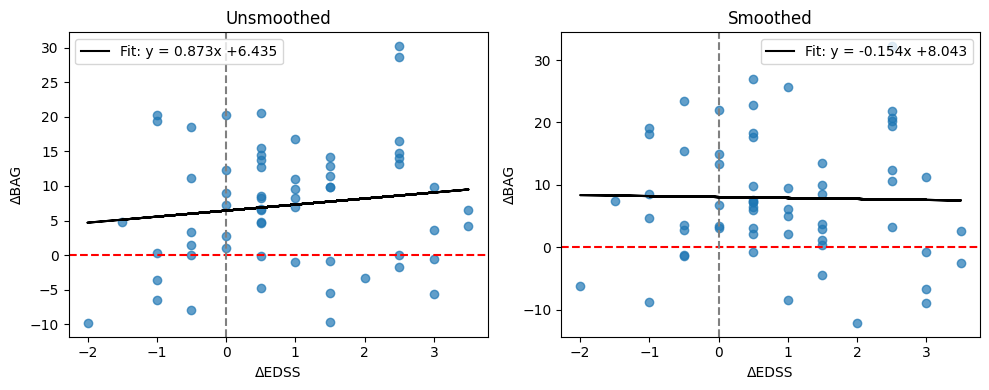

Using BAG column: delta_BAG
Unsmoothed n = 61
Smoothed n = 61


In [12]:
# Plot change in EDSS against change in residual BAG
plot_bag_vs_delta_clinical_two_models(df_delta_unsmooth,df_delta_smooth,delta_clinical_col="delta_EDSS", delta_bag_col="delta_BAG",
                                      x_label="ΔEDSS", y_label="ΔBAG")



### Correlation: ΔEDSS and ΔBAG

In [13]:
def pearson_ci(r, n):
    """
    Calculate a 95% confidence interval for a Pearson correlation coefficient
    using Fisher's z-transformation.
    """
    # Transform r to Fisher's z scale
    z = np.arctanh(r)

    # Standard error of Fisher's z
    se = 1 / np.sqrt(n - 3)

    # Critical value for a 95% confidence interval
    z_crit = 1.96

    # Lower and upper limits on the z scale
    lo = z - z_crit * se
    hi = z + z_crit * se

    # Transform limits back to the correlation scale
    return np.tanh(lo), np.tanh(hi)


def safe_pearson(df, x, y, label, model_name):
    """
    Calculate Pearson correlation between two variables after removing missing values.

    The function prints:
    - correlation coefficient r
    - 95% confidence interval
    - p-value
    - sample size
    """

    # Keep only the two columns needed for the correlation
    tmp = df[[x, y]].copy()

    # Remove infinite and missing values
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

    # Calculate Pearson correlation
    r, p = pearsonr(tmp[x], tmp[y])

    # Number of observations included
    n = len(tmp)

    # Confidence interval for r
    ci_lo, ci_hi = pearson_ci(r, n)

    # Print formatted output
    print(f"\n===== {label} | {model_name} =====")
    print(f"{x} vs {y}")
    print(f"r = {r:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], p = {p:.3e}, n = {n}")
    
    return r, p, ci_lo, ci_hi

In [14]:
# Correlate change in residual BAG with change in EDSS
safe_pearson(df_delta_unsmooth, "delta_BAG", "delta_EDSS","ΔBAG vs ΔEDSS", "Unsmoothed")

safe_pearson(df_delta_smooth, "delta_BAG", "delta_EDSS","ΔBAG vs ΔEDSS", "Smoothed")


===== ΔBAG vs ΔEDSS | Unsmoothed =====
delta_BAG vs delta_EDSS
r = 0.130, 95% CI [-0.126, 0.370], p = 3.177e-01, n = 61

===== ΔBAG vs ΔEDSS | Smoothed =====
delta_BAG vs delta_EDSS
r = -0.021, 95% CI [-0.271, 0.232], p = 8.735e-01, n = 61


(np.float64(-0.020819752785484764),
 np.float64(0.8734634970268469),
 np.float64(-0.27122291608824106),
 np.float64(0.2322229458299937))

Observation:

The unsmoothed model showed a weak positive correlation, while the smoothed model showed almost no correlation. In both cases, the relationship was not statistically significant.

### Plot: Baseline BAG vs ΔEDSS 

This is a predictive analysis. It investigates whether residual BAG at baseline is associated with later change in EDSS from baseline to month 120.

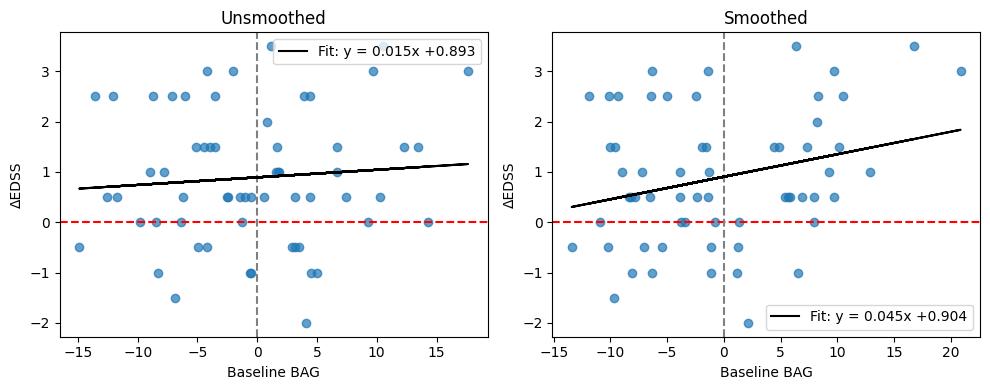

Using BAG column: delta_EDSS
Unsmoothed n = 61
Smoothed n = 61


In [15]:
# Plot baseline residual BAG against later EDSS change
# Here, baseline BAG is used as the predictor and ΔEDSS is the outcome
plot_bag_vs_delta_clinical_two_models(
    df_delta_unsmooth,
    df_delta_smooth,
    delta_clinical_col="BAG_BL",   # x-akse
    delta_bag_col="delta_EDSS",    # y-akse
    x_label="Baseline BAG",
    y_label="ΔEDSS"
)

### Correlation: Baseline BAG and ΔEDSS

In [16]:
# Correlate baseline residual BAG with later EDSS change
# This evaluates whether baseline BAG has predictive value for disability progression
safe_pearson(df_delta_unsmooth,"BAG_BL","delta_EDSS","Baseline BAG vs ΔEDSS","Unsmoothed")

safe_pearson(df_delta_smooth,"BAG_BL","delta_EDSS","Baseline BAG vs ΔEDSS","Smoothed")


===== Baseline BAG vs ΔEDSS | Unsmoothed =====
BAG_BL vs delta_EDSS
r = 0.083, 95% CI [-0.173, 0.328], p = 5.264e-01, n = 61

===== Baseline BAG vs ΔEDSS | Smoothed =====
BAG_BL vs delta_EDSS
r = 0.264, 95% CI [0.013, 0.484], p = 3.960e-02, n = 61


(np.float64(0.2642536752306782),
 np.float64(0.03959707943545428),
 np.float64(0.01331453228333074),
 np.float64(0.4838787786762783))

Observation:

For the unsmoothed model, there was no statistically significant relationship between baseline residual BAG and later EDSS change. For the smoothed model, a weak positive association was observed and reached statistical significance.

### Plot: ΔFatigue and ΔBAG

Fatigue change is calculated between baseline and month 24 because fatigue information is not available at month 120. For consistency, ΔBAG in this fatigue analysis is also calculated between baseline and month 24.

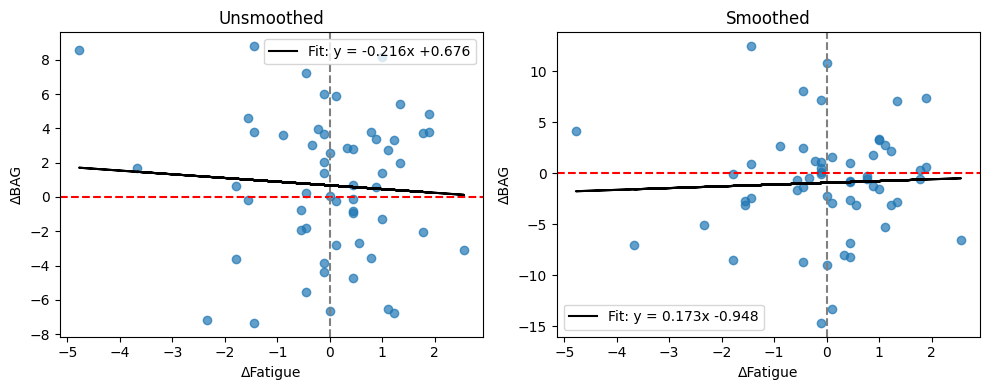

Using BAG column: delta_BAG_f
Unsmoothed n = 57
Smoothed n = 57


In [17]:
# Plot change in fatigue against change in residual BAG
plot_bag_vs_delta_clinical_two_models(df_delta_unsmooth,df_delta_smooth,delta_clinical_col="delta_fatigue",delta_bag_col="delta_BAG_f",
                                      x_label="ΔFatigue", y_label="ΔBAG")


### Correlation: ΔFatigue and ΔBAG

In [18]:
# Correlate change in residual BAG with change in fatigue
safe_pearson(df_delta_unsmooth, "delta_BAG_f", "delta_fatigue","ΔBAG vs ΔFatigue", "Unsmoothed")
safe_pearson(df_delta_smooth, "delta_BAG_f", "delta_fatigue","ΔBAG vs ΔFatigue", "Smoothed")


===== ΔBAG vs ΔFatigue | Unsmoothed =====
delta_BAG_f vs delta_fatigue
r = -0.069, 95% CI [-0.324, 0.195], p = 6.095e-01, n = 57

===== ΔBAG vs ΔFatigue | Smoothed =====
delta_BAG_f vs delta_fatigue
r = 0.044, 95% CI [-0.220, 0.301], p = 7.478e-01, n = 57


(np.float64(0.04353255698528852),
 np.float64(0.7478052486112972),
 np.float64(-0.2195298774287802),
 np.float64(0.30069389791824686))

Observation: 

No statistically significant association was found between changes in residual BAG and changes in fatigue for either the unsmoothed or smoothed model.

### Plot: Baseline BAG vs ΔFatigue

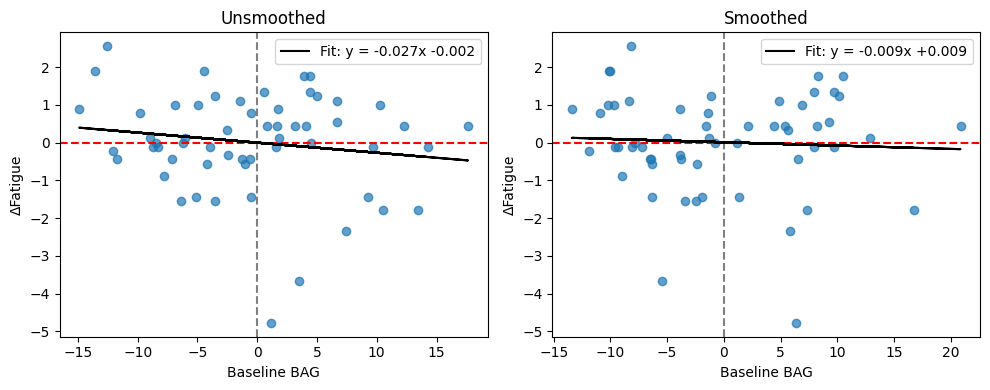

Using BAG column: delta_fatigue
Unsmoothed n = 57
Smoothed n = 57


In [19]:
# Plot baseline residual BAG against later fatigue change
plot_bag_vs_delta_clinical_two_models(
    df_delta_unsmooth,
    df_delta_smooth,
    delta_clinical_col="BAG_BL",   # x-akse
    delta_bag_col="delta_fatigue",    # y-akse
    x_label="Baseline BAG",
    y_label="ΔFatigue"
)

### Correlation: Baseline BAG and ΔFatigue

In [20]:
# Correlate baseline residual BAG with later fatigue change
safe_pearson(df_delta_unsmooth,"BAG_BL","delta_fatigue","Baseline BAG vs ΔFatigue","Unsmoothed")

safe_pearson(df_delta_smooth,"BAG_BL","delta_fatigue","Baseline BAG vs ΔFatigue","Smoothed")


===== Baseline BAG vs ΔFatigue | Unsmoothed =====
BAG_BL vs delta_fatigue
r = -0.152, 95% CI [-0.397, 0.113], p = 2.588e-01, n = 57

===== Baseline BAG vs ΔFatigue | Smoothed =====
BAG_BL vs delta_fatigue
r = -0.054, 95% CI [-0.310, 0.210], p = 6.915e-01, n = 57


(np.float64(-0.0537034202738865),
 np.float64(0.6915475218199201),
 np.float64(-0.309938483648708),
 np.float64(0.20980473199803415))

Observation:

No statistically significant relationship was found between baseline residual BAG and later change in fatigue for either model.